1. Notebook Structure

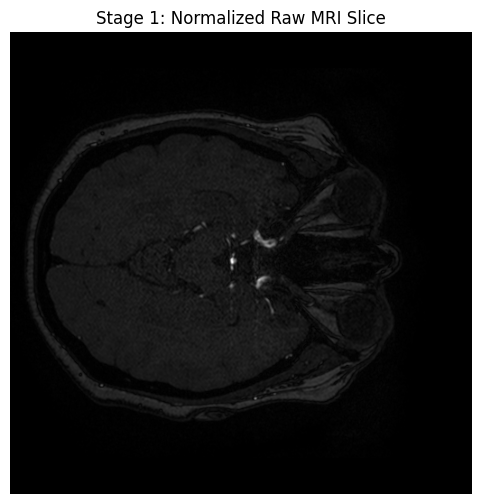

In [1]:
# Cell 1: Environment Setup
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.append('..')
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.operators import apply_sobel, apply_canny, apply_log, apply_kirsch, apply_roberts, apply_prewitt, apply_frei_chen
from src.metrics import create_tissue_mask, binarize_edge_map

# Load a sample slice
sample_path = 'C:\\Users\\Divine\\Desktop\\Image Sharpening Project\\biomed-edge-detection\\data\\processed\\mri\\mri_v0_s20.npy' # Update with an actual filename you have
img = np.load(sample_path)

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.title("Stage 1: Normalized Raw MRI Slice")
plt.axis('off')
plt.show()

2. Stage 2: The ROI Masking


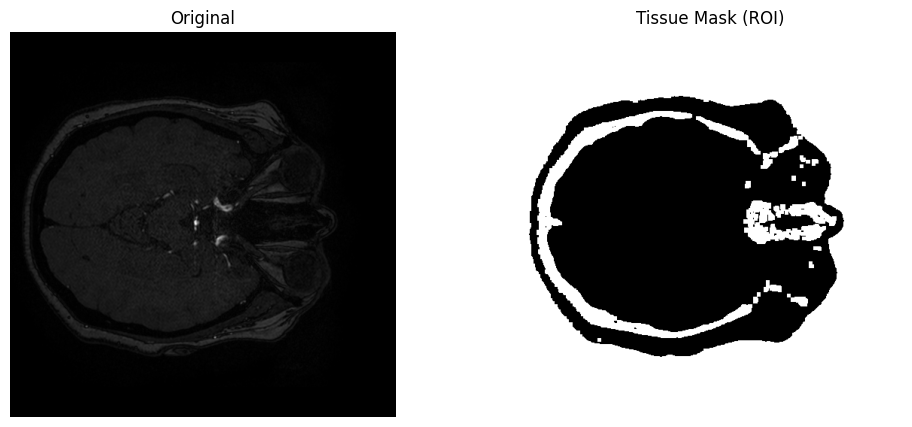

In [3]:
mask = create_tissue_mask(img)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original")
axes[1].imshow(mask, cmap='binary')
axes[1].set_title("Tissue Mask (ROI)")
for ax in axes: ax.axis('off')
plt.show()

3. Stage 3: The Operator Comparison

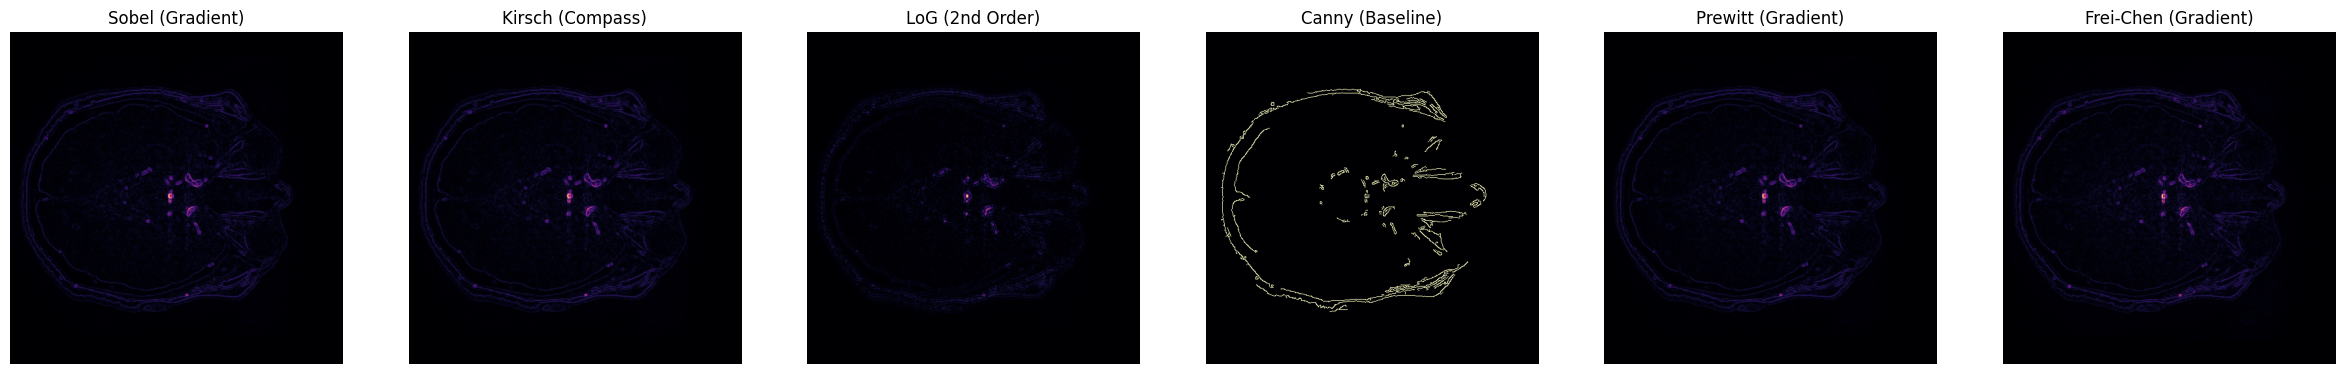

In [4]:
# Apply operators
sobel = apply_sobel(img)
kirsch = apply_kirsch(img)
log = apply_log(img)
canny = apply_canny(img)
prewitt = apply_prewitt(img)
roberts = apply_roberts(img)
frei_chen = apply_frei_chen(img)
# Plotting
fig, axes = plt.subplots(1, 6, figsize=(30, 5))
titles = ["Sobel (Gradient)", "Kirsch (Compass)", "LoG (2nd Order)", "Canny (Baseline)", "Prewitt (Gradient)", "Frei-Chen (Gradient)"]
images = [sobel, kirsch, log, canny, prewitt, roberts, frei_chen]

for ax, im, title in zip(axes, images, titles):
    ax.imshow(im, cmap='magma') # 'magma' helps visualize low-intensity edges
    ax.set_title(title)
    ax.axis('off')
plt.show()

4. Stage 4: Binarization & Evaluation (Pratt's FOM Prep)

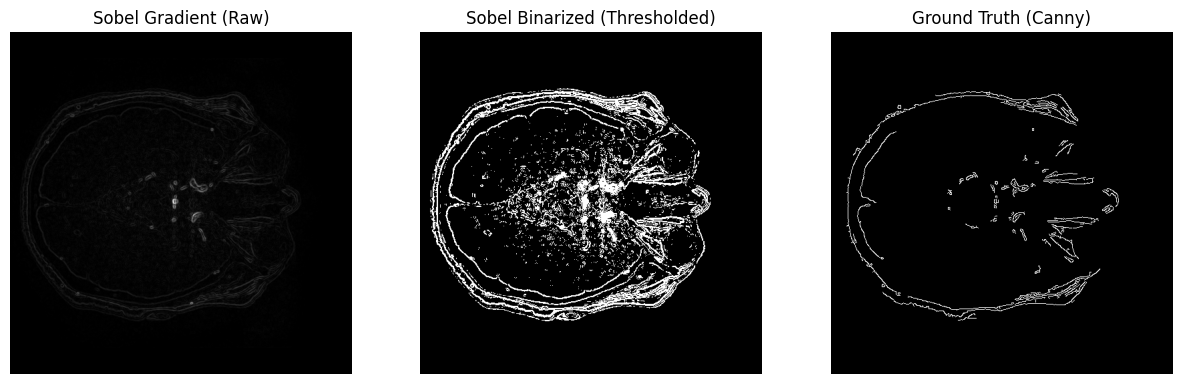

In [5]:
# Binarize a gradient operator
sobel_bin = binarize_edge_map(sobel)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sobel, cmap='gray')
axes[0].set_title("Sobel Gradient (Raw)")
axes[1].imshow(sobel_bin, cmap='gray')
axes[1].set_title("Sobel Binarized (Thresholded)")
axes[2].imshow(canny, cmap='gray')
axes[2].set_title("Ground Truth (Canny)")

for ax in axes: ax.axis('off')
plt.show()

5. Stage 5: The "Difference Map"

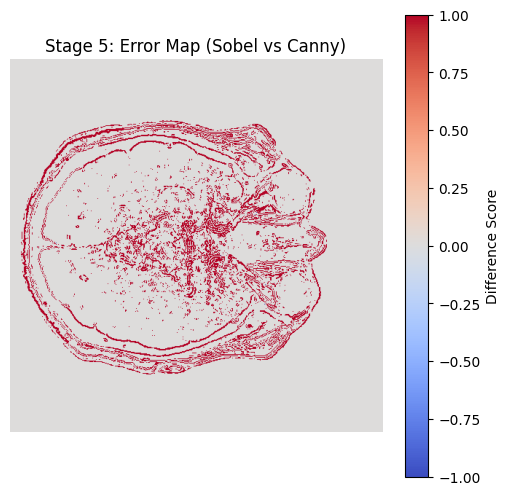

In [6]:
# Simple difference visualization
diff = sobel_bin.astype(float) - canny.astype(float)

plt.figure(figsize=(6, 6))
plt.imshow(diff, cmap='coolwarm') # Red/Blue shows where they differ
plt.title("Stage 5: Error Map (Sobel vs Canny)")
plt.colorbar(label="Difference Score")
plt.axis('off')
plt.show()